# Imports

In [49]:
import os
import keras
from PIL import Image
from keras import layers
import matplotlib.pyplot as plt

# Importering av data

In [40]:
if not os.path.exists("data/fashion_mnist_images/train") or not os.path.exists("data/fashion_mnist_images/test"):
    # raderar fel plaserad data eller gammal data
    
    if os.path.exists("data/fashion_mnist_images") and not os.path.exists("data/fashion_mnist_images/train") and not os.path.exists("data/fashion_mnist_images/test"): 
        print("starting to overwrite old data")
        for folder_name in os.listdir("data/fashion_mnist_images"):
            folder_path = os.path.join("data/fashion_mnist_images", folder_name)

            for file_name in os.listdir(folder_path):
                file_path = os.path.join(folder_path ,file_name)
                print(f"is file: {os.path.isfile(file_path)}, {file_path}")
                
                os.remove(file_path)  # Remove the file
                #print(f"removed file {file_path}")
        
        os.rmdir(folder_path)
        print(f"--removed folder {folder_path}")
                
    #  Ladda dataset
        (x_train, y_train),(x_test, y_test) = keras.datasets.fashion_mnist.load_data()

    # Klassnamn (viktigt för mappar)
        class_names = [
            "T-shirt_top", "Trouser", "Pullover", "Dress", "Coat",
            "Sandal", "Shirt", "Sneaker", "Bag", "Ankle_boot"
        ]

        # Root folder
        base_path = "data/fashion_mnist_images"

        # Skapa mappar per klass för tränings data
        if not os.path.exists(f"{base_path}/train"):

            for class_name in class_names:
                os.makedirs(os.path.join(base_path,"train", class_name), exist_ok=True)

            # Spara träningsbilder
            for i, (img, label) in enumerate(zip(x_train, y_train)):

                class_name = class_names[label]
                
                path = os.path.join(base_path,"train", class_name, f"{i}.png")

                image = Image.fromarray(img)  # numpy → bild
                image.save(path)
        else:
             print("Test data already importet")

        if not os.path.exists(f"{base_path}/test"):
            # Skapa mappar per klass på test data

            for class_name in class_names:
                os.makedirs(os.path.join(base_path,"test", class_name), exist_ok=True)

            # Spara testbilder
            for i, (img, label) in enumerate(zip(x_test, y_test)):

                class_name = class_names[label]

                path = os.path.join(base_path,"test", class_name, f"{i}.png")

                image = Image.fromarray(img)  # numpy → bild
                image.save(path)
        else: 
             print("Train data already importet")

        print("Done with importing data")
else:
     print("Data already been imported")

Data already been imported


# Standard model

## Inläsning av data

In [41]:
train_dir = "data/fashion_mnist_images/train"
test_dir = "data/fashion_mnist_images/test"


IMG_SIZE = (48, 48)
BATCH_SIZE = 128

train_data = keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = keras.utils.image_dataset_from_directory(
    test_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
class_names = train_data.class_names
normalization_layer = layers.Rescaling(1./255)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


## Första modelen

In [42]:
model_1 = keras.Sequential([
    layers.Input(shape=(48,48,1)),
    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,434 (3.20 MB)

 Trainable params: 839,434 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

## Träning

In [43]:
history_1 = model_1.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - accuracy: 0.8339 - loss: 0.4611 - val_accuracy: 0.8656 - val_loss: 0.3798
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.8904 - loss: 0.3042 - val_accuracy: 0.8877 - val_loss: 0.3126
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - accuracy: 0.9071 - loss: 0.2588 - val_accuracy: 0.8946 - val_loss: 0.2859
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 114ms/step - accuracy: 0.9130 - loss: 0.2333 - val_accuracy: 0.9021 - val_loss: 0.2634
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 171ms/step - accuracy: 0.9270 - loss: 0.2013 - val_accuracy: 0.9003 - val_loss: 0.2782
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 76s 161ms/step - accuracy: 0.9353 - loss: 0.1781 - val_accuracy: 0.9078 - val_loss: 0.2559
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 190ms/step - accuracy: 0.9433 - loss: 0.1544 - val_accuracy: 0.9119 - val_loss: 0.2540
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - accuracy: 0.9507 - loss: 0.1

# Jämförelse Model

## Inläsning av data

## Data föränding

## Andra model

## Träning

# Jämförelse

model 1


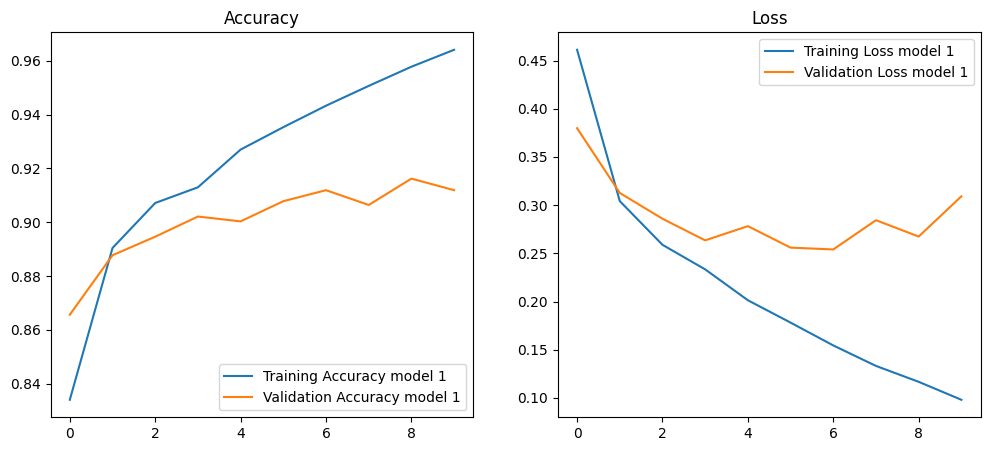

In [50]:

print("model 1")
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']

loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy model 1')
plt.plot(epochs_range, val_acc, label='Validation Accuracy model 1')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss model 1')
plt.plot(epochs_range, val_loss, label='Validation Loss model 1')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()